In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
# Read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


## Build Dataset

In [5]:
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
    
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix] # crop and append
X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [53]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## Implementing the embedding lookup table

In [7]:
C = torch.randn((27, 2)) # character embedding matrix
emb = C[X] # embed the characters into vectors
emb.shape

torch.Size([228146, 3, 2])

In [8]:
emb[0] # the first batch which was '...' is now three vectors of dimension 2, where each vector is the embedding of the character '.' (which has index 0 in the vocabulary)
# The same will be done for each batch, so we will get a 3D tensor of shape (number of batches, block_size, embedding_dim)

tensor([[-0.0626, -0.8355],
        [-0.0626, -0.8355],
        [-0.0626, -0.8355]])

## Implementing the hidden layer

In [9]:
w1 = torch.randn((6, 100)) # the weight matrix for the hidden layer
# We take 6 because we have 2 dimensions in the embedding, and a block size of 3, so we have 2*3=6 inputs to the hidden layer
b1 = torch.randn(100) # the bias for the hidden layer

In [10]:
torch.cat(torch.unbind(emb, 1), dim=1).shape # less efficient

torch.Size([228146, 6])

In [12]:
h = torch.tanh(emb.view(-1, 6) @ w1 + b1)

In [13]:
h

tensor([[-0.9991,  0.9090, -0.0835,  ...,  0.5464,  0.3059, -0.5365],
        [ 0.0653,  0.9916,  0.9967,  ...,  0.5668, -0.5360, -0.0898],
        [-1.0000, -0.5118, -0.9662,  ...,  0.3050, -0.3867,  0.6997],
        ...,
        [-1.0000,  0.9226, -0.9221,  ...,  0.6533, -0.9359, -0.9964],
        [-1.0000,  0.9881, -0.6417,  ...,  0.9907, -0.9377, -0.9931],
        [ 0.6666,  0.9968,  0.9975,  ...,  0.9962,  0.7987,  0.9414]])

## Implementing the output layer

In [14]:
w2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [15]:
logits = h @ w2 + b2
logits.shape

torch.Size([228146, 27])

In [16]:
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
probs.shape

torch.Size([228146, 27])

In [17]:
loss = -probs[torch.arange(len(Y)), Y].log().mean()
loss

tensor(16.5426)

### Summary

In [54]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [55]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g) # character embedding matrix
w1 = torch.randn((6, 100), generator=g) # the weight matrix for the character embedding to hidden layer
b1 = torch.randn(100, generator=g) # the bias for the hidden layer
w2 = torch.randn((100, 27), generator=g) # the weight matrix for the hidden layer to output layer
b2 = torch.randn(27, generator=g) # the bias for the output layer
parameters = [C, w1, b1, w2, b2]

In [56]:
sum(p.nelement() for p in parameters) # number of parameters in the model

3481

In [57]:
for p in parameters:
    p.requires_grad = True

In [48]:
lre = torch.linspace(-3, 0, 1000) # learning rates to try
lrs = 10**lre

In [65]:
lri = []
lossi = []
for i in range(10000):
    
    # minibatch construct
    ix = torch.randint(0, len(Xtr), (32,))
    
    # forward pass
    emb = C[Xtr[ix]] # embed the characters into vectors
    h = torch.tanh(emb.view(-1, 6) @ w1 + b1) # (32, 100)
    logits = h @ w2 + b2 # (32, 27)
    # counts = logits.exp()
    # probs = counts / counts.sum(1, keepdim=True)
    # loss = -probs[torch.arange(len(Y)), Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix]) # this is more numerically stable than the above
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    # lr = lrs[i] # learning rate
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    # track status
    # lri.append(lre[i].item())
    # lossi.append(loss.item())
        
print(loss.item())

2.3118436336517334


training split, dev/validation split, test split

80%, 10%, 10%

In [66]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 6) @ w1 + b1)
logits = h @ w2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3374, grad_fn=<NllLossBackward0>)

## Larger Hidden layer and Increasing the character embeddings

In [85]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g) # character embedding matrix
w1 = torch.randn((30, 200), generator=g) # the weight matrix for the character embedding to hidden layer
b1 = torch.randn(200, generator=g) # the bias for the hidden layer
w2 = torch.randn((200, 27), generator=g) # the weight matrix for the hidden layer to output layer
b2 = torch.randn(27, generator=g) # the bias for the output layer
parameters = [C, w1, b1, w2, b2]

In [86]:
sum(p.nelement() for p in parameters) # number of parameters in the model

11897

In [87]:
for p in parameters:
    p.requires_grad = True

In [88]:
lri = []
lossi = []
stepi = []

In [92]:
for i in range(50000):
    
    # minibatch construct
    ix = torch.randint(0, len(Xtr), (32,))
    
    # forward pass
    emb = C[Xtr[ix]] # embed the characters into vectors
    h = torch.tanh(emb.view(-1, 30) @ w1 + b1) # (32, 200)
    logits = h @ w2 + b2 # (32, 27)
    # counts = logits.exp()
    # probs = counts / counts.sum(1, keepdim=True)
    # loss = -probs[torch.arange(len(Y)), Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix]) # this is more numerically stable than the above
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    # lr = lrs[i] # learning rate
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    # track status
    stepi.append(i)
    # lri.append(lre[i].item())
    lossi.append(loss.log10().item())
        
print(loss.item())

2.272984027862549


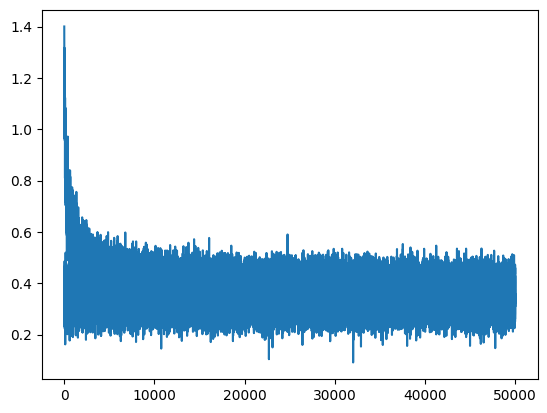

In [93]:
plt.plot(stepi, lossi)

In [94]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ w1 + b1)
logits = h @ w2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2012, grad_fn=<NllLossBackward0>)

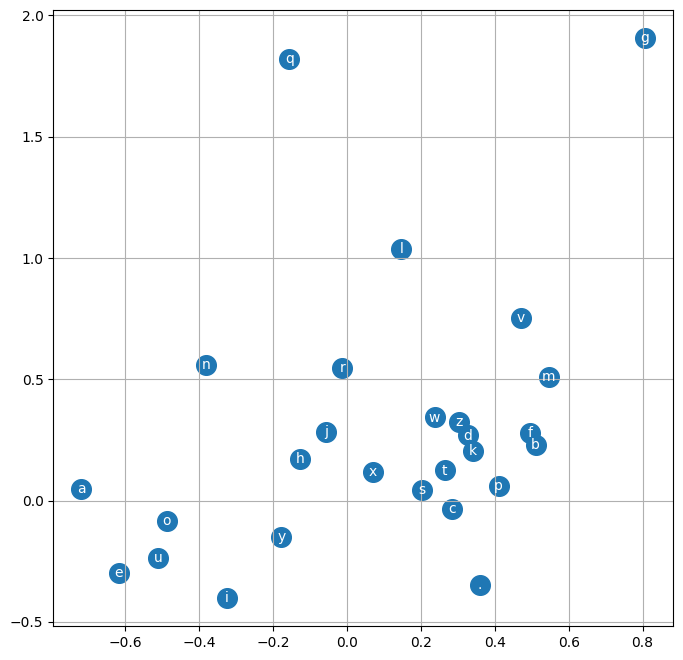

In [84]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [96]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ w1 + b1)
      logits = h @ w2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
amille.
khy.
mili.
thiyah.
cassie.
rahuen.
den.
rhy.
kaqui.
ner.
kia.
chriiv.
kaleigh.
ham.
jori.
quinn.
suline.
liveni.
wazelo.
